In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully! ✅")

All libraries loaded successfully! ✅


In [2]:
df = pd.read_csv('HR_Employee_Data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 18)

First 5 rows:


,EmployeeID,Age,Gender,MaritalStatus,Department,JobRole,EducationField,MonthlyIncome,YearsAtCompany,YearsWithCurrManager,JobSatisfaction,PerformanceRating,WorkLifeBalance,OverTime,BusinessTravel,Attrition,AgeGroup,AttritionFlag
0,EMP0001,23,Male,Single,Operations,Operations Manager,Life Sciences,9303,5,2,2,2,1,Yes,Non-Travel,No,21-25,0
1,EMP0002,23,Male,Divorced,HR,Recruiter,Technical Degree,5932,4,1,4,3,3,Yes,Travel_Rarely,No,21-25,0
2,EMP0003,35,Female,Divorced,Technology,Data Analyst,Life Sciences,6879,10,1,4,2,3,No,Travel_Rarely,No,26-35,0
3,EMP0004,40,Male,Single,Sales,Sales Representative,Life Sciences,4481,20,19,2,3,1,Yes,Travel_Rarely,No,36-45,0
4,EMP0005,45,Male,Single,Technology,Developer,Technical Degree,9455,5,2,2,3,1,Yes,Travel_Rarely,No,36-45,0


In [3]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EmployeeID            200 non-null    object
 1   Age                   200 non-null    int64 
 2   Gender                200 non-null    object
 3   MaritalStatus         200 non-null    object
 4   Department            200 non-null    object
 5   JobRole               200 non-null    object
 6   EducationField        200 non-null    object
 7   MonthlyIncome         200 non-null    int64 
 8   YearsAtCompany        200 non-null    int64 
 9   YearsWithCurrManager  200 non-null    int64 
 10  JobSatisfaction       200 non-null    int64 
 11  PerformanceRating     200 non-null    int64 
 12  WorkLifeBalance       200 non-null    int64 
 13  OverTime              200 non-null    object
 14  BusinessTravel        200 non-null    object
 15  Attrition             200 

,Age,MonthlyIncome,YearsAtCompany,YearsWithCurrManager,JobSatisfaction,PerformanceRating,WorkLifeBalance,AttritionFlag
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,40.480000,7301.455000,8.710000,4.580000,2.555000,3.015000,2.520000,0.100000
std,10.162973,2118.163082,5.710424,4.574739,1.110469,0.705168,1.142861,0.300753
min,22.000000,3304.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,31.000000,5491.250000,4.000000,1.000000,2.000000,3.000000,2.000000,0.000000
50%,40.000000,7252.500000,8.000000,3.000000,3.000000,3.000000,2.000000,0.000000
75%,48.250000,8889.750000,13.000000,6.250000,4.000000,3.000000,4.000000,0.000000
max,58.000000,11607.000000,20.000000,20.000000,4.000000,4.000000,4.000000,1.000000


In [4]:
print("Attrition Count:")
print(df['Attrition'].value_counts())
print("\nAttrition Rate:", 
      round(df['Attrition'].value_counts()['Yes']/len(df)*100, 2), "%")

Attrition Count:
Attrition
No     180
Yes     20
Name: count, dtype: int64

Attrition Rate: 10.0 %


C:\Users\Mariselvan\AppData\Local\Temp\ipykernel_18148\3302254443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Attrition',


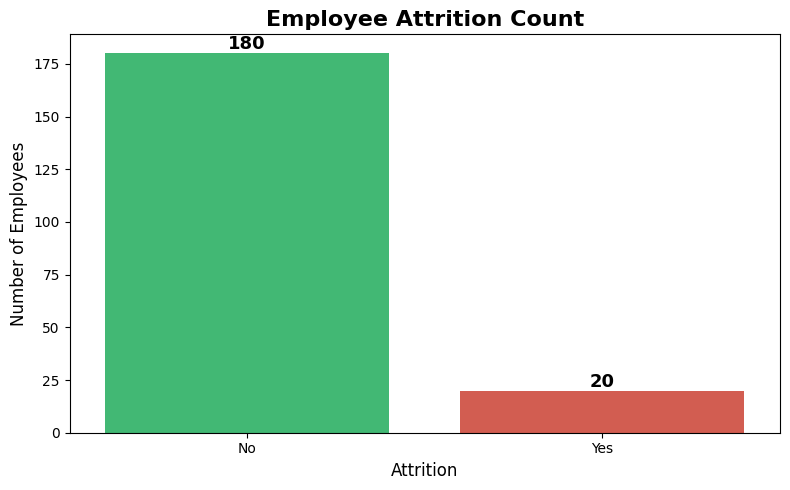

Chart 1 saved! ✅


In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Attrition', 
                   palette=['#2ecc71', '#e74c3c'])
plt.title('Employee Attrition Count', fontsize=16, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_attrition_count.png', dpi=150)
plt.show()
print("Chart 1 saved! ✅")

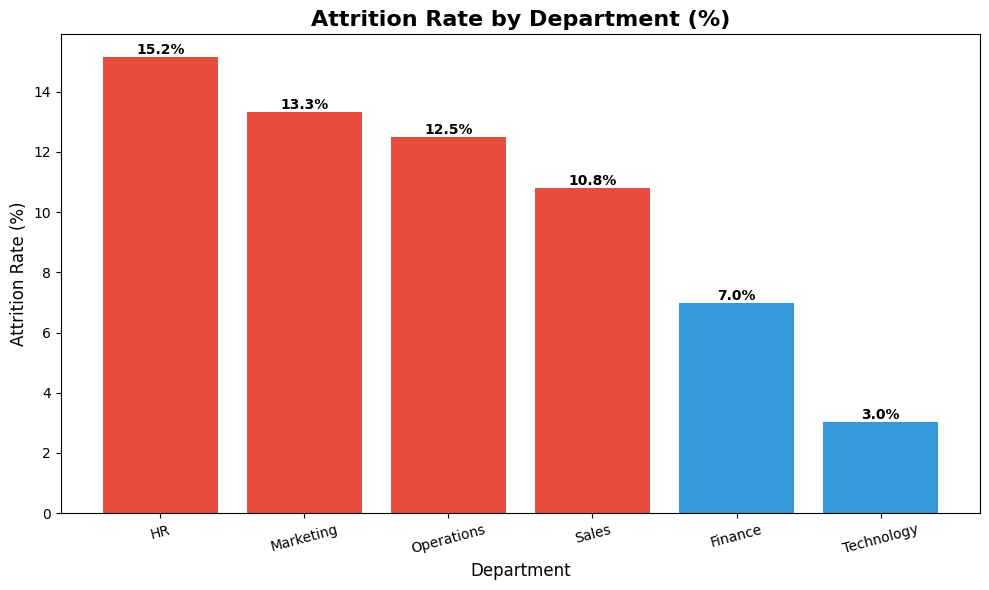

Chart 2 saved! ✅


In [6]:
plt.figure(figsize=(10, 6))
dept_attr = df.groupby('Department')['AttritionFlag'].mean() * 100
dept_attr = dept_attr.sort_values(ascending=False)
colors = ['#e74c3c' if x > 10 else '#3498db' for x in dept_attr.values]
bars = plt.bar(dept_attr.index, dept_attr.values, color=colors)
plt.title('Attrition Rate by Department (%)', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.xticks(rotation=15)
for bar, val in zip(bars, dept_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_dept_attrition.png', dpi=150)
plt.show()
print("Chart 2 saved! ✅")

C:\Users\Mariselvan\AppData\Local\Temp\ipykernel_18148\1873394302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='MonthlyIncome',


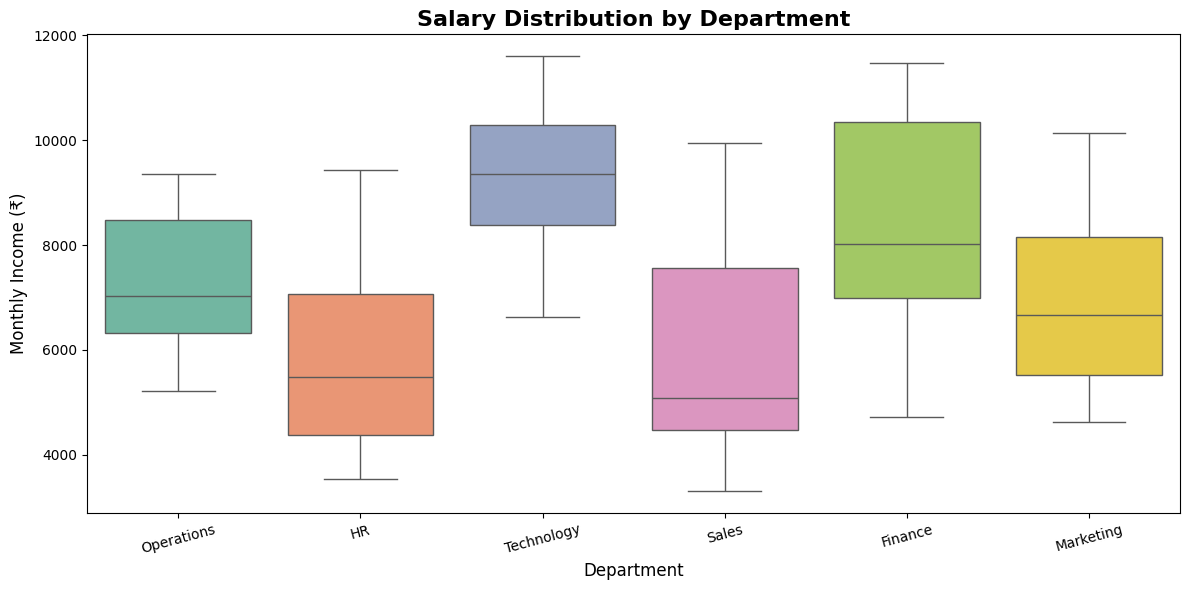

Salary Distibution by department


In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Department', y='MonthlyIncome', 
            palette='Set2')
plt.title('Salary Distribution by Department', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Monthly Income (₹)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart3_salary_distribution.png', dpi=150)
plt.show()
print("Salary Distibution by department")

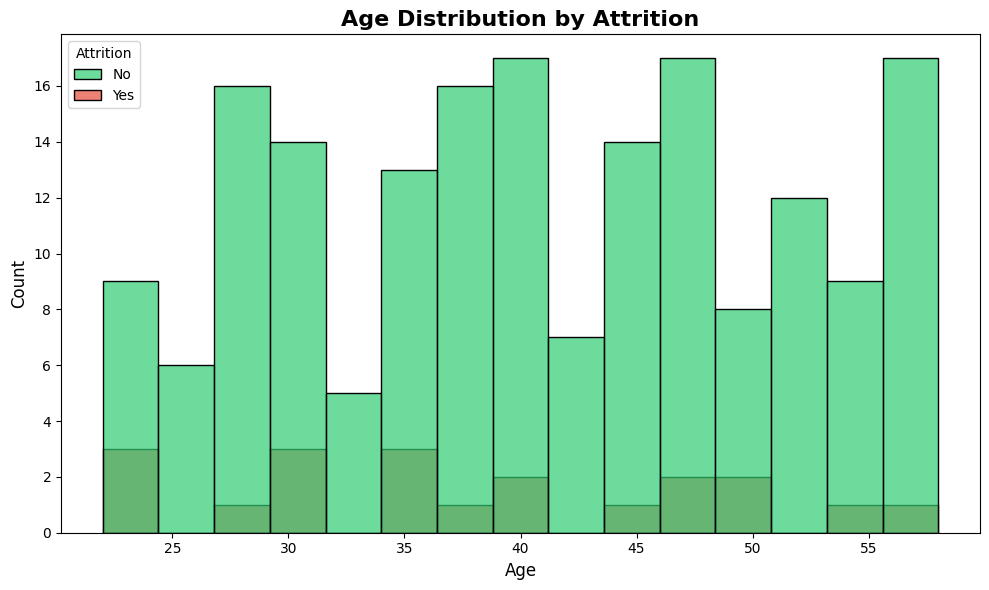

Age distribution


In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Attrition', 
             bins=15, palette=['#2ecc71','#e74c3c'], alpha=0.7)
plt.title('Age Distribution by Attrition', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_age_distribution.png', dpi=150)
plt.show()
print("Age distribution")

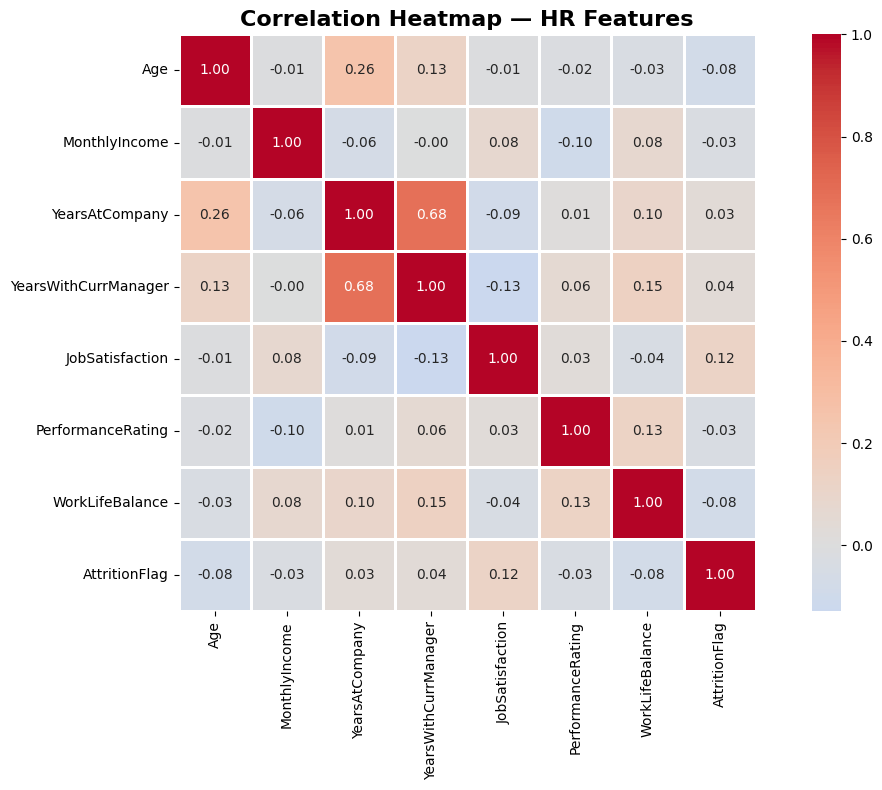

Correlation heat map


In [9]:
plt.figure(figsize=(12, 8))
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 
                'YearsWithCurrManager', 'JobSatisfaction', 
                'PerformanceRating', 'WorkLifeBalance', 'AttritionFlag']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap — HR Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png', dpi=150)
plt.show()
print("Correlation heat map")